#**APE005 - Distribuciones Discretas Notables**

**Grupo:** H **| Autores:**
* Sherman Abarca
* Valeria Aguila
* Domenica Narvaez
* Gabriel Suarez
* Diyer Torres
* José Valencia

## **Tarea 1: Modelado Computacional de la Distribución Binomial**
La distribución Binomial modela el número de éxitos  $x$ en $n$  ensayos independientes de Bernoulli, con probabilidad de éxito $P$ . Su PMF está dada por:

$$P(X = k) = \binom{n}{k} p^k (1 - p)^{n-k}$$

Abra un nuevo Jupyter Notebook llamado APE_006_Distribuciones.ipynb.
Suponga un escenario de control de calidad de software donde un lote de 20 microservicios tiene una probabilidad del 15% de fallar bajo estrés. Escriba y ejecute el siguiente código:


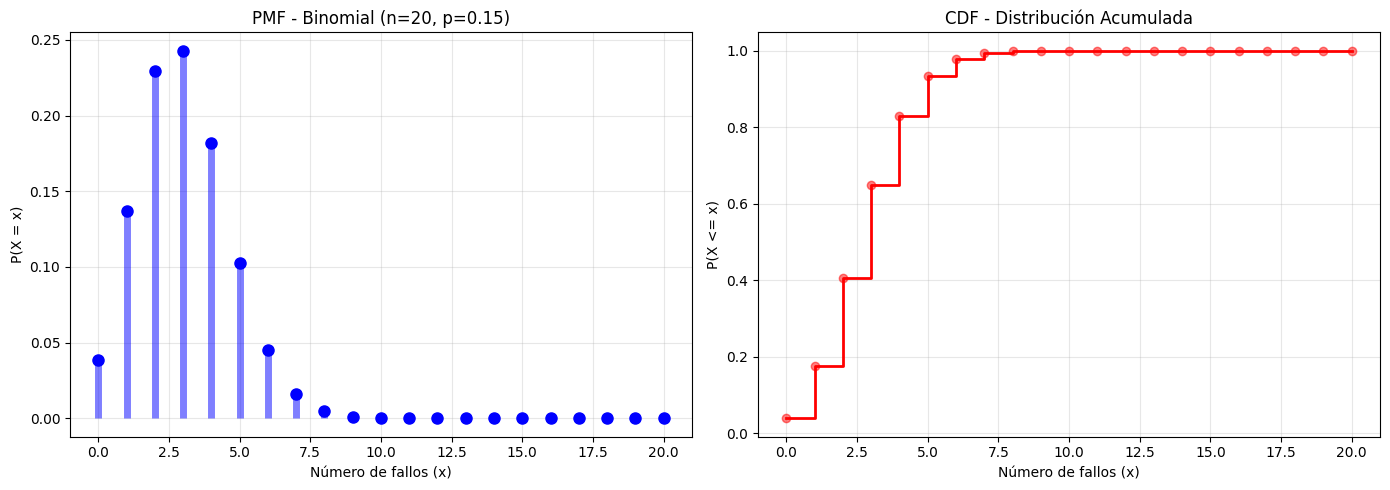

La probabilidad de tener 3 fallos o menos es: 0.6477


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Parámetros del modelo Binomial
n_ensayos = 20
p_falla = 0.15

# Dominio de la variable aleatoria (0 a n)
x = np.arange(0, n_ensayos + 1)

# Cálculo de PMF (Función de Masa) y CDF (Función Acumulada)
pmf_binomial = binom.pmf(x, n_ensayos, p_falla)
cdf_binomial = binom.cdf(x, n_ensayos, p_falla)

# Visualización
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico PMF
ax[0].vlines(x, 0, pmf_binomial, colors='b', lw=5, alpha=0.5)
ax[0].plot(x, pmf_binomial, 'bo', ms=8)
ax[0].set_title(f'PMF - Binomial (n={n_ensayos}, p={p_falla})')
ax[0].set_xlabel('Número de fallos (x)')
ax[0].set_ylabel('P(X = x)')
ax[0].grid(True, alpha=0.3)

# Gráfico CDF
ax[1].step(x, cdf_binomial, where='post', color='r', lw=2)
ax[1].plot(x, cdf_binomial, 'ro', alpha=0.5)
ax[1].set_title('CDF - Distribución Acumulada')
ax[1].set_xlabel('Número de fallos (x)')
ax[1].set_ylabel('P(X <= x)')
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Cálculo de probabilidad específica: P(X <= 3)
prob_max_3 = binom.cdf(3, n_ensayos, p_falla)
print(f"La probabilidad de tener 3 fallos o menos es: {prob_max_3:.4f}")


## **Tarea 2: Modelado de la Distribución de Poisson (Eventos Raros)**
La distribución de Poisson modela el número de eventos que ocurren en un intervalo de tiempo o espacio continuo, con una tasa media conocida $\lambda$ . Su PMF es:

$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$$

Suponga que los servidores de la universidad en Loja reciben en promedio
$\lambda = 4.5$ peticiones de acceso erróneas por minuto.
Basándose en la estructura del código de la Tarea 1, implemente la simulación
utilizando scipy.stats.poisson. Grafique únicamente la PMF evaluando desde
$X = 0$ hasta $X = 5$.
Calcule mediante código la probabilidad exacta de recibir exactamente 6
peticiones erróneas en un minuto: $P(X = x)$

<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_41188/4286937754.py:19: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'Distribución de Poisson - Peticiones Erróneas ($\lambda$={media_peticiones})')


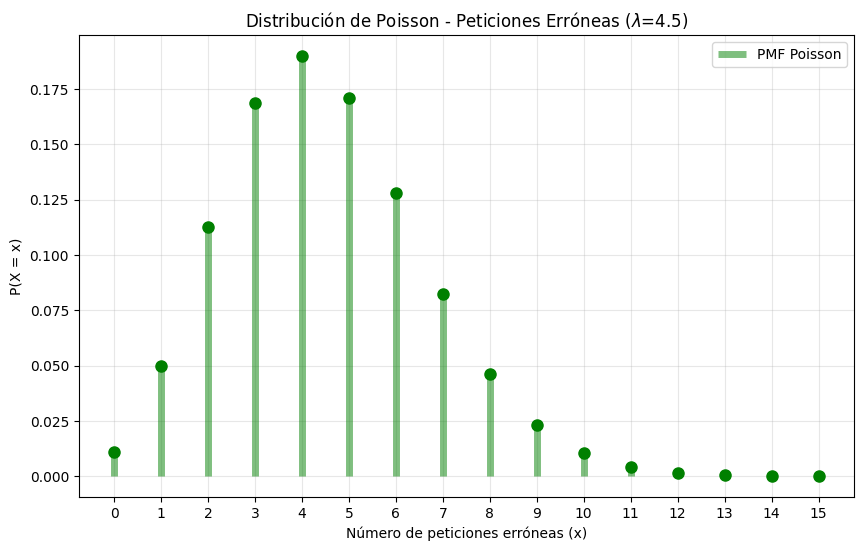

La probabilidad exacta de recibir 6 peticiones erróneas es: 0.1281


In [ ]:
from scipy.stats import poisson

# Parámetros del modelo de Poisson
# La media (lambda) es 4.5 peticiones por minuto
media_peticiones = 4.5

# Dominio de la variable aleatoria: de x = 0 hasta x = 15
x = np.arange(0, 16)

# Cálculo de la PMF (Función de Masa de Probabilidad)
pmf_poisson = poisson.pmf(x, media_peticiones)

# Visualización de la PMF
plt.figure(figsize=(10, 6))
plt.vlines(x, 0, pmf_poisson, colors='g', lw=5, alpha=0.5, label='PMF Poisson')
plt.plot(x, pmf_poisson, 'go', ms=8)

# Configuración del gráfico
plt.title(f'Distribución de Poisson - Peticiones Erróneas ($\lambda$={media_peticiones})')
plt.xlabel('Número de peticiones erróneas (x)')
plt.ylabel('P(X = x)')
plt.xticks(x)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Cálculo de probabilidad específica: P(X = 6)
# Probabilidad de recibir exactamente 6 peticiones en un minuto
prob_exacta_6 = poisson.pmf(6, media_peticiones)
print(f"La probabilidad exacta de recibir 6 peticiones erróneas es: {prob_exacta_6:.4f}")

## **Tarea 3: Hito del Proyecto - Identificación de Variables de Conteo (ABP)**

Cargue su dataset regional en pandas.

Identifique una variable discreta que represente un "conteo" (ej. número de accidentes semanales en Loja, número de transacciones diarias, cantidad de clientes por hora).

Calcule la media muestral ($\bar{x}$) de esa variable y asuma que es el parámetro $\lambda$ para un modelo de Poisson teórico.

Genere un gráfico superponiendo el histograma de densidad de su variable empírica contra la línea de la PMF teórica de Poisson generada en scipy.

Discuta visualmente si los datos reales siguen esta distribución.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 3._remuneraciones_ingresos_adicionales.xlsx to 3._remuneraciones_ingresos_adicionales.xlsx


In [ ]:
import pandas as pd
import seaborn as sns

# Carga del dataset
df = pd.read_excel('3._remuneraciones_ingresos_adicionales.xlsx')

print('📋 Primeras filas del dataset:')
display(df.head())

print(f'\n📐 Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'\n📝 Columnas disponibles:')
for col in df.columns:
    print(f'   - {col}')

📋 Primeras filas del dataset:


,Numeración,Puesto Institucional,Régimen laboral al que pertenece,Número de partida presupuestaria,Grado jerárquico o escala al que pertenece el puesto,Remuneración mensual unificada,Remuneración unificada (anual),Décimo Tercera Remuneración,Décima Cuarta Remuneración,Horas suplementarias y extraordinarias,Encargos y subrogaciones,Total ingresos adicionales
0,1,AGENTE CIVIL DE TRANSITO 1°,LOSEP,4.01.01.001.002.7.1.01.05,Servidor Público de Apoyo 4,733.0,8796.00,61.08,35.42,0.0,0.0,96.50
1,2,OFICINISTA,LOSEP,3.06.01.001.001.5.1.01.05,Servidor Público de Apoyo 2,622.0,7464.00,51.83,35.42,0.0,0.0,87.25
2,3,JEFE OPERATIVO DE TRANSITO (E),LOSEP,1.01.01.001.001.5.1.01.05,Servidor Público 7,1676.0,12159.31,139.67,35.42,0.0,0.0,175.09
3,4,PROMOTOR SOCIAL,LOSEP,1.01.01.001.001.5.1.01.05,Servidor Público 1,817.0,9804.00,68.08,35.42,0.0,0.0,103.50
4,5,DOCENTE DE UNIDAD EDUCATIVA MUNICIPAL,LOSEP,2.01.01.001.001.7.1.01.05,Servidor Público 1,817.0,9804.00,68.08,35.42,0.0,0.0,103.50



📐 Dimensiones: 2883 filas x 12 columnas

📝 Columnas disponibles:
   - Numeración
   - Puesto Institucional 
   - Régimen laboral al que pertenece 
   - Número de partida presupuestaria
   - Grado jerárquico o escala al que pertenece el puesto
   - Remuneración mensual unificada
   - Remuneración unificada (anual)
   - Décimo Tercera Remuneración
   - Décima Cuarta Remuneración
   - Horas suplementarias y extraordinarias
   - Encargos y subrogaciones
   - Total ingresos adicionales


La media muestral (lambda) es: 30.1286


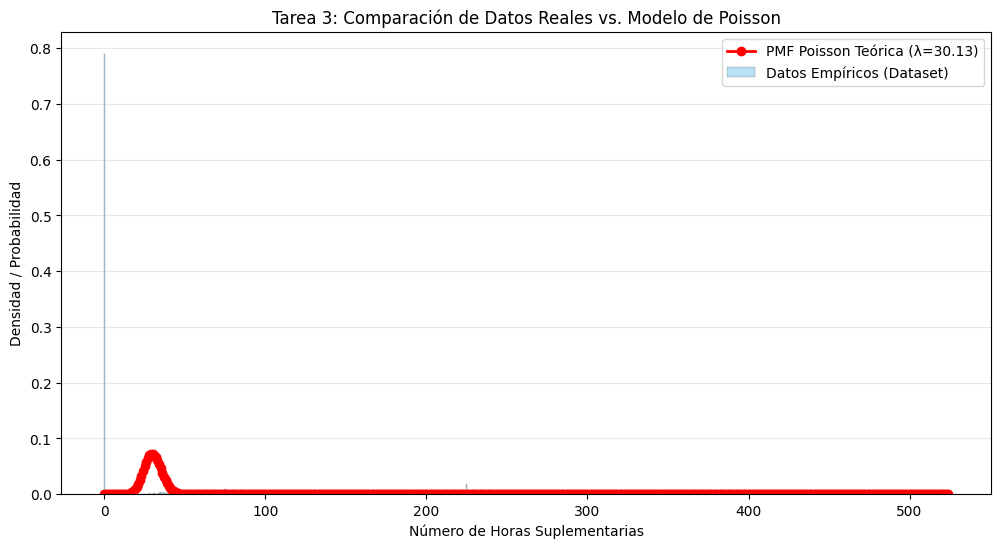

In [ ]:
# 2. Identificación de la variable de conteo (ABP)
# Usaremos 'Horas suplementarias y extraordinarias' como nuestra variable de interés
variable_conteo = df['Horas suplementarias y extraordinarias'].dropna()

# 3. Cálculo de la media muestral (lambda empírico)
lambda_empirico = variable_conteo.mean()
print(f"La media muestral (lambda) es: {lambda_empirico:.4f}")

# 4. Preparación de la PMF teórica de Poisson
# Creamos un rango de x que cubra los valores observados en nuestros datos
x_teorico = np.arange(0, variable_conteo.max() + 1)
pmf_teorica = poisson.pmf(x_teorico, lambda_empirico)

# 5. Visualización: Superposición de Histograma vs PMF Teórica
plt.figure(figsize=(12, 6))

# Histograma de los datos reales (Empírico)
sns.histplot(variable_conteo, kde=False, stat="density", color="skyblue",
             label="Datos Empíricos (Dataset)", discrete=True, alpha=0.6)

# Línea de la PMF de Poisson (Teórico)
plt.plot(x_teorico, pmf_teorica, 'ro-', lw=2, label=f'PMF Poisson Teórica (λ={lambda_empirico:.2f})')

# Configuración del gráfico
plt.title('Tarea 3: Comparación de Datos Reales vs. Modelo de Poisson')
plt.xlabel('Número de Horas Suplementarias')
plt.ylabel('Densidad / Probabilidad')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## **Tarea 4: ABI - Aproximación Binomial a Poisson**

Investigue bajo qué condiciones matemáticas una distribución Binomial se aproxima a una de Poisson.
Redacte un bloque Markdown explicando la relación $\lambda = n \cdot p$ cuando $n \to \infty$ y $p \to 0$.

Escriba un pequeño script en Python que calcule $P(X = x)$ usando un modelo Binomial con $n = 1000$ y $p = 0.003$ , y compare el resultado imprimiendo también el valor de $P(X = x)$ en un modelo de Poisson donde $\lambda = 1000 \cdot 0.003 = 3$. Demuestre que los valores son casi idénticos.


----
**Relación Teórica:**
Una distribución Binomial $B(n, p)$ se aproxima a una distribución de Poisson $P(\lambda)$ cuando el número de ensayos $n$ tiende a infinito ($n \to \infty$) y la probabilidad de éxito $p$ tiende a cero ($p \to 0$). En este caso, el parámetro de la Poisson se define como $\lambda = n \cdot p$. Esta aproximación es muy útil en "eventos raros" donde hay muchas oportunidades de que ocurra algo, pero la probabilidad de que ocurra en cada intento es mínima.

In [ ]:
from scipy.stats import binom, poisson

# Parámetros para la demostración
n = 1000
p = 0.01
k = 10
lambda_calc = n * p  # lambda = 10

# 1. Cálculo con modelo Binomial
prob_binomial = binom.pmf(k, n, p)

# 2. Cálculo con modelo de Poisson
prob_poisson = poisson.pmf(k, lambda_calc)

print(f"--- Comparación de Resultados (k={k}) ---")
print(f"Probabilidad Binomial (n={n}, p={p}): {prob_binomial:.6f}")
print(f"Probabilidad Poisson (lambda={lambda_calc}): {prob_poisson:.6f}")
print(f"Diferencia: {abs(prob_binomial - prob_poisson):.6e}")

--- Comparación de Resultados (k=10) ---
Probabilidad Binomial (n=1000, p=0.01): 0.125740
Probabilidad Poisson (lambda=10.0): 0.125110
Diferencia: 6.301754e-04
